<a href="https://colab.research.google.com/github/alfionsoderoso7/customer-churn-naive-bayes/blob/main/Riski_Cahya_Alfiansyah_Customer_Naive_Bayes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ============================================
# GAUSSIAN NAIVE BAYES - CUSTOMER CHURN PREDICTION
# ============================================

# 1. IMPORT LIBRARY
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [6]:
# ============================================
# 2. LOAD DATA
# ============================================
df = pd.read_csv('/content/data_ecommerce_customer_churn.csv')

print("=" * 50)
print("DATA INFO")
print("=" * 50)
print(f"Jumlah data: {len(df)}")
print(f"Jumlah fitur: {len(df.columns)}")
print(f"\nMissing values per kolom:")
print(df.isnull().sum())

print("\n5 Data Pertama:")
print(df.head())

DATA INFO
Jumlah data: 3941
Jumlah fitur: 11

Missing values per kolom:
Tenure                      194
WarehouseToHome             169
NumberOfDeviceRegistered      0
PreferedOrderCat              0
SatisfactionScore             0
MaritalStatus                 0
NumberOfAddress               0
Complain                      0
DaySinceLastOrder           213
CashbackAmount                0
Churn                         0
dtype: int64

5 Data Pertama:
   Tenure  WarehouseToHome  NumberOfDeviceRegistered    PreferedOrderCat  \
0    15.0             29.0                         4  Laptop & Accessory   
1     7.0             25.0                         4              Mobile   
2    27.0             13.0                         3  Laptop & Accessory   
3    20.0             25.0                         4             Fashion   
4    30.0             15.0                         4              Others   

   SatisfactionScore MaritalStatus  NumberOfAddress  Complain  \
0                  3    

In [7]:
# ============================================
# 3. PREPROCESSING
# ============================================

# 3.1 Handle Missing Values
print("\n" + "=" * 50)
print("PREPROCESSING - HANDLING MISSING VALUES")
print("=" * 50)

# Untuk fitur numerik: isi dengan median
numerical_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
                  'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder',
                  'CashbackAmount']

for col in numerical_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  {col}: diisi dengan median = {median_val:.2f}")

# Untuk fitur kategorikal: isi dengan modus
categorical_cols = ['PreferedOrderCat', 'MaritalStatus']

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  {col}: diisi dengan modus = {mode_val}")


PREPROCESSING - HANDLING MISSING VALUES
  Tenure: diisi dengan median = 9.00
  WarehouseToHome: diisi dengan median = 14.00
  DaySinceLastOrder: diisi dengan median = 3.00


/tmp/ipykernel_6323/835278883.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


In [8]:
# 3.2 Encoding Fitur Kategorikal
print("\n" + "=" * 50)
print("PREPROCESSING - ENCODING CATEGORICAL FEATURES")
print("=" * 50)

# Label Encoding untuk PreferedOrderCat
le_order = LabelEncoder()
df['PreferedOrderCat'] = le_order.fit_transform(df['PreferedOrderCat'])
print(f"  PreferedOrderCat: {dict(zip(le_order.classes_, le_order.transform(le_order.classes_)))}")

# Label Encoding untuk MaritalStatus
le_marital = LabelEncoder()
df['MaritalStatus'] = le_marital.fit_transform(df['MaritalStatus'])
print(f"  MaritalStatus: {dict(zip(le_marital.classes_, le_marital.transform(le_marital.classes_)))}")


PREPROCESSING - ENCODING CATEGORICAL FEATURES
  PreferedOrderCat: {'Fashion': np.int64(0), 'Grocery': np.int64(1), 'Laptop & Accessory': np.int64(2), 'Mobile': np.int64(3), 'Mobile Phone': np.int64(4), 'Others': np.int64(5)}
  MaritalStatus: {'Divorced': np.int64(0), 'Married': np.int64(1), 'Single': np.int64(2)}


In [9]:
# 3.3 Pisahkan Fitur (X) dan Target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

print(f"\nFitur (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")
print(f"\nDistribusi Target (Churn):")
print(f"  Tidak Churn (0): {(y == 0).sum()} ({((y==0).sum()/len(y))*100:.1f}%)")
print(f"  Churn (1)     : {(y == 1).sum()} ({((y==1).sum()/len(y))*100:.1f}%)")


Fitur (X) shape: (3941, 10)
Target (y) shape: (3941,)

Distribusi Target (Churn):
  Tidak Churn (0): 3267 (82.9%)
  Churn (1)     : 674 (17.1%)


In [10]:
# 3.4 Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nSplit Data:")
print(f"  Training set : {len(X_train)} data")
print(f"  Testing set  : {len(X_test)} data")


Split Data:
  Training set : 3152 data
  Testing set  : 789 data


Bagian ini mengekstrak variabel target 'name' dari DataFrame dan menyimpannya dalam variabel `y`.

In [11]:
# 3.5 Standard Scaling (PENTING untuk Gaussian Naive Bayes)
# Karena Gaussian NB mengasumsikan data berdistribusi normal
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nStandardScaler: semua fitur telah distandarisasi (mean=0, std=1)")


StandardScaler: semua fitur telah distandarisasi (mean=0, std=1)


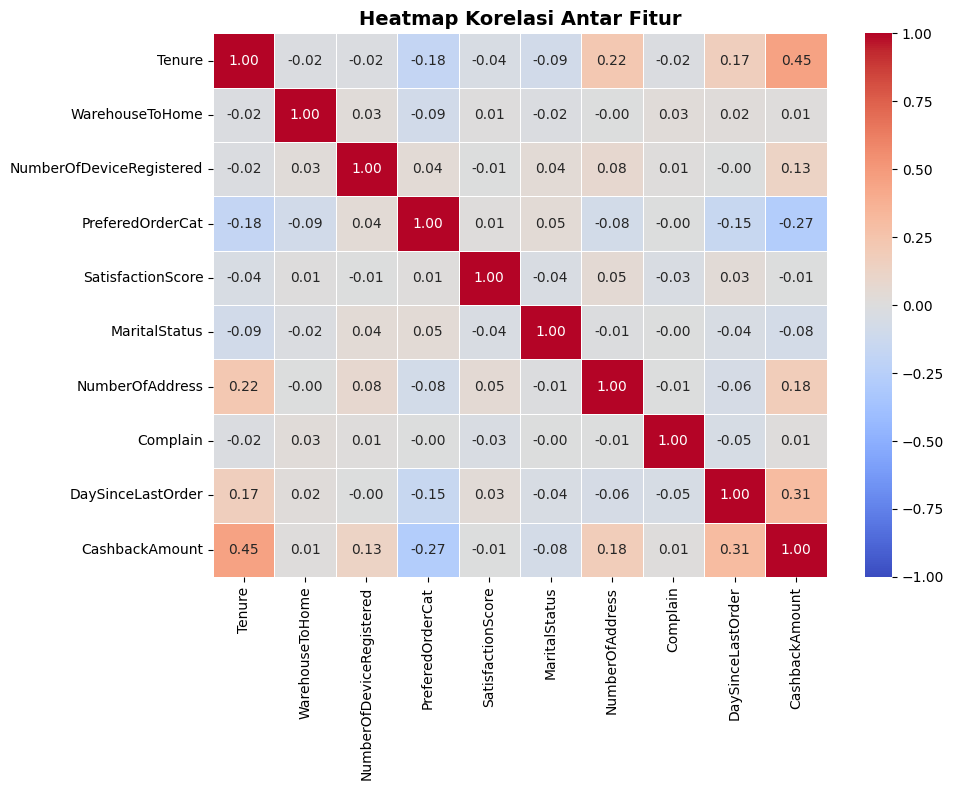

In [12]:
# ============================================
# 4. VISUALISASI KORELASI (seperti di materi PPT)
# ============================================
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Heatmap Korelasi Antar Fitur', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

In [13]:
# ============================================
# 5. TRAINING MODEL GAUSSIAN NAIVE BAYES
# ============================================
print("\n" + "=" * 50)
print("TRAINING GAUSSIAN NAIVE BAYES")
print("=" * 50)

# Inisialisasi model GaussianNB
gnb = GaussianNB()

# Training model
gnb.fit(X_train_scaled, y_train)
print("Model berhasil dilatih!")

# Parameter model
print(f"\nParameter GaussianNB:")
print(f"  priors        : {gnb.priors}")
print(f"  var_smoothing : {gnb.var_smoothing}")


TRAINING GAUSSIAN NAIVE BAYES
Model berhasil dilatih!

Parameter GaussianNB:
  priors        : None
  var_smoothing : 1e-09


In [14]:
# ============================================
# 6. EVALUASI MODEL
# ============================================
print("\n" + "=" * 50)
print("EVALUASI MODEL")
print("=" * 50)

# Prediksi pada data testing
y_pred = gnb.predict(X_test_scaled)

# Akurasi
akurasi = accuracy_score(y_test, y_pred)
print(f"\nAKURASI: {akurasi:.4f} ({akurasi*100:.2f}%)")

# Classification Report
print("\nCLASSIFICATION REPORT:")
print("-" * 40)
print(classification_report(y_test, y_pred, target_names=['Tidak Churn (0)', 'Churn (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX:")
print("-" * 40)
print(f"                 Prediksi")
print(f"                 Tidak Churn  Churn")
print(f"Aktual Tidak Churn    {cm[0,0]:4d}      {cm[0,1]:4d}")
print(f"Aktual Churn          {cm[1,0]:4d}      {cm[1,1]:4d}")


EVALUASI MODEL

AKURASI: 0.8580 (85.80%)

CLASSIFICATION REPORT:
----------------------------------------
                 precision    recall  f1-score   support

Tidak Churn (0)       0.92      0.91      0.91       654
      Churn (1)       0.58      0.59      0.59       135

       accuracy                           0.86       789
      macro avg       0.75      0.75      0.75       789
   weighted avg       0.86      0.86      0.86       789


CONFUSION MATRIX:
----------------------------------------
                 Prediksi
                 Tidak Churn  Churn
Aktual Tidak Churn     597        57
Aktual Churn            55        80


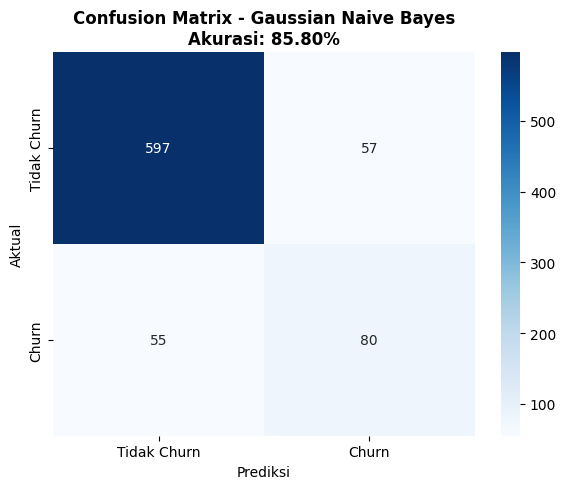

In [15]:
# ============================================
# 7. VISUALISASI CONFUSION MATRIX
# ============================================
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'])
plt.title(f'Confusion Matrix - Gaussian Naive Bayes\nAkurasi: {akurasi*100:.2f}%',
          fontweight='bold', fontsize=12)
plt.ylabel('Aktual')
plt.xlabel('Prediksi')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [16]:
# ============================================
# 8. ANALISIS TAMBAHAN - PROBABILITAS PREDIKSI
# ============================================
print("\n" + "=" * 50)
print("ANALISIS PROBABILITAS PREDIKSI")
print("=" * 50)

# Ambil 5 data testing pertama
print("\nContoh 5 data testing pertama beserta probabilitas prediksi:")
print("-" * 70)

y_pred_proba = gnb.predict_proba(X_test_scaled[:5])

for i in range(5):
    print(f"\nData ke-{i+1}:")
    print(f"  Aktual          : {y_test.iloc[i]}")
    print(f"  Prediksi        : {y_pred[i]}")
    print(f"  Probabilitas    : P(Churn=0) = {y_pred_proba[i][0]:.4f}, P(Churn=1) = {y_pred_proba[i][1]:.4f}")
    print(f"  Status          : {'✓ BENAR' if y_pred[i] == y_test.iloc[i] else '✗ SALAH'}")


ANALISIS PROBABILITAS PREDIKSI

Contoh 5 data testing pertama beserta probabilitas prediksi:
----------------------------------------------------------------------

Data ke-1:
  Aktual          : 0
  Prediksi        : 0
  Probabilitas    : P(Churn=0) = 0.9986, P(Churn=1) = 0.0014
  Status          : ✓ BENAR

Data ke-2:
  Aktual          : 0
  Prediksi        : 0
  Probabilitas    : P(Churn=0) = 0.9590, P(Churn=1) = 0.0410
  Status          : ✓ BENAR

Data ke-3:
  Aktual          : 0
  Prediksi        : 0
  Probabilitas    : P(Churn=0) = 0.7182, P(Churn=1) = 0.2818
  Status          : ✓ BENAR

Data ke-4:
  Aktual          : 0
  Prediksi        : 0
  Probabilitas    : P(Churn=0) = 0.9348, P(Churn=1) = 0.0652
  Status          : ✓ BENAR

Data ke-5:
  Aktual          : 0
  Prediksi        : 0
  Probabilitas    : P(Churn=0) = 0.5113, P(Churn=1) = 0.4887
  Status          : ✓ BENAR


In [17]:
# ============================================
# 9. RINGKASAN HASIL
# ============================================
print("\n" + "=" * 50)
print("RINGKASAN HASIL")
print("=" * 50)
print(f"""
┌─────────────────────────────────────────────────────────────┐
│                    GAUSSIAN NAIVE BAYES                     │
│                   CUSTOMER CHURN PREDICTION                 │
├─────────────────────────────────────────────────────────────┤
│  Total Data           : {len(df)}                                   │
│  Training Data        : {len(X_train)}                                   │
│  Testing Data         : {len(X_test)}                                   │
├─────────────────────────────────────────────────────────────┤
│  AKURASI              : {akurasi*100:.2f}%                             │
├─────────────────────────────────────────────────────────────┤
│  CONFUSION MATRIX:                                            │
│    - True Negative   : {cm[0,0]:4d} (Tidak Churn → Tidak Churn)      │
│    - False Positive  : {cm[0,1]:4d} (Tidak Churn → Churn)           │
│    - False Negative  : {cm[1,0]:4d} (Churn → Tidak Churn)           │
│    - True Positive   : {cm[1,1]:4d} (Churn → Churn)                 │
├─────────────────────────────────────────────────────────────┤
│  PRECISION (Churn)   : {classification_report(y_test, y_pred, output_dict=True)['1']['precision']:.4f}    │
│  RECALL (Churn)      : {classification_report(y_test, y_pred, output_dict=True)['1']['recall']:.4f}    │
│  F1-SCORE (Churn)    : {classification_report(y_test, y_pred, output_dict=True)['1']['f1-score']:.4f}    │
└─────────────────────────────────────────────────────────────┘
""")


RINGKASAN HASIL

┌─────────────────────────────────────────────────────────────┐
│                    GAUSSIAN NAIVE BAYES                     │
│                   CUSTOMER CHURN PREDICTION                 │
├─────────────────────────────────────────────────────────────┤
│  Total Data           : 3941                                   │
│  Training Data        : 3152                                   │
│  Testing Data         : 789                                   │
├─────────────────────────────────────────────────────────────┤
│  AKURASI              : 85.80%                             │
├─────────────────────────────────────────────────────────────┤
│  CONFUSION MATRIX:                                            │
│    - True Negative   :  597 (Tidak Churn → Tidak Churn)      │
│    - False Positive  :   57 (Tidak Churn → Churn)           │
│    - False Negative  :   55 (Churn → Tidak Churn)           │
│    - True Positive   :   80 (Churn → Churn)                 │
├───────────